In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dataset Path: /content/drive/MyDrive/archive
Files: ['heart_disease_combined.csv', 'heart_disease_cleveland.csv']

First 5 Rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target     source  
0    3.0  0.0   6.0       0  cleveland  
1    2.0  3.0   3.0       1  cleveland  
2    2.0  2.0   7.0       1  cleveland  
3    3.0  0.0   3.0       0  cleveland  
4    1.0  0.0   3.0       0  cleveland  

Shape: (920, 15)

Columns: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'

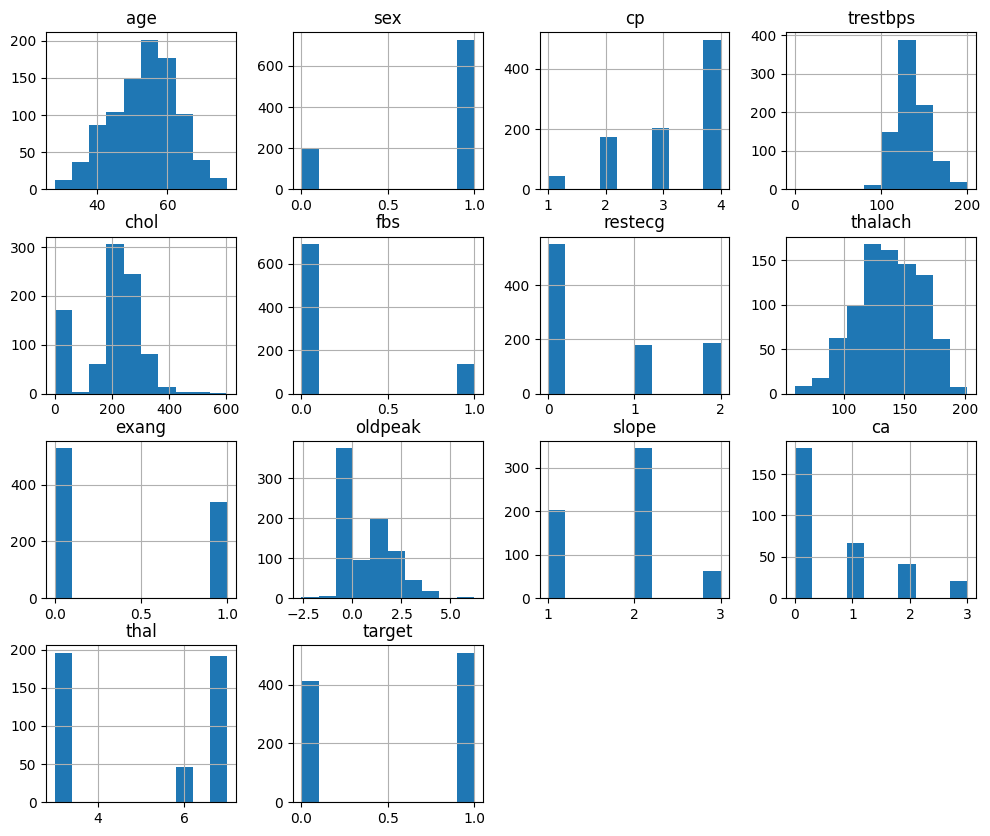

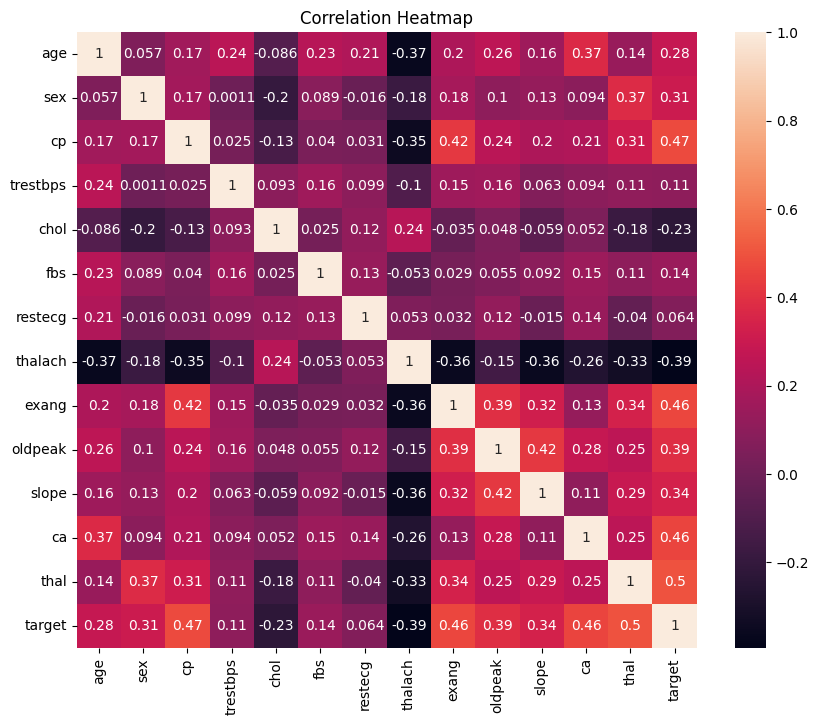

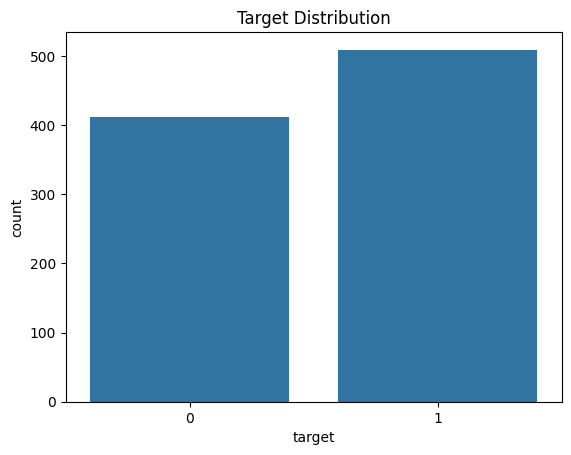


Accuracy: 0.8478260869565217


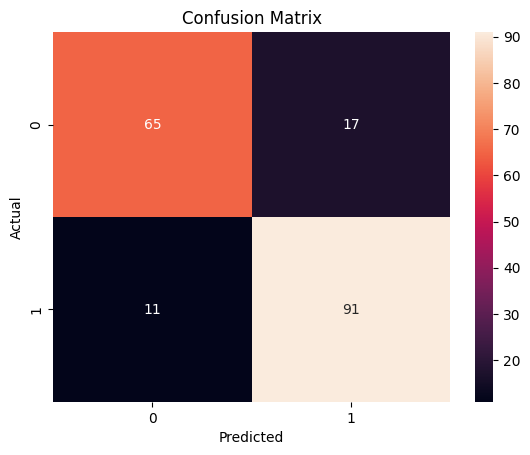


Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.79      0.82        82
           1       0.84      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



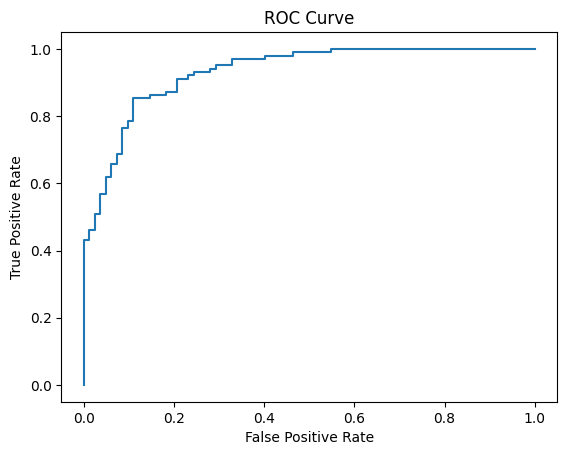

AUC Score: 0.9312529890004781


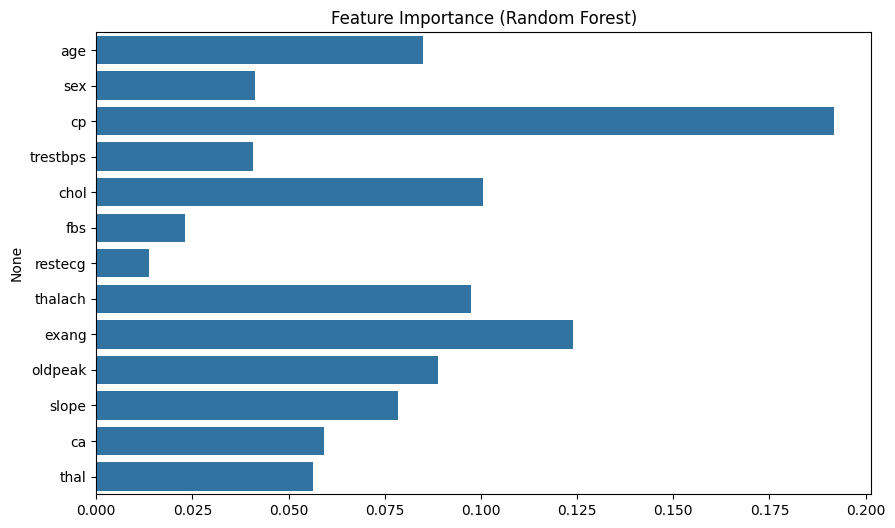

In [11]:
# ================== IMPORT LIBRARIES ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ================== LOAD DATASET ==================
path = "/content/drive/MyDrive/archive"

print("Dataset Path:", path)
print("Files:", os.listdir(path))

df = pd.read_csv(path + "/heart_disease_combined.csv")

print("\nFirst 5 Rows:")
print(df.head())

# ================== BASIC INFO ==================
print("\nShape:", df.shape)
print("\nColumns:", df.columns)
print("\nSummary:")
print(df.describe())

# ================== EDA ==================
df_numeric = df.drop(columns=['source'], errors='ignore')

df_numeric.hist(figsize=(12,10))
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df_numeric.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

# ================== SPLIT DATA ==================
X = df.drop(columns=['target', 'source'], errors='ignore')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================== MISSING VALUE HANDLING ==================
imputer = SimpleImputer(strategy='mean')

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

# ================== FEATURE SCALING ==================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================== MODEL TRAIN ==================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

# ================== PREDICTION ==================
y_pred = model.predict(X_test)

# ================== EVALUATION ==================
print("\nAccuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ================== ROC & AUC ==================
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

# ================== FEATURE IMPORTANCE (⭐ ADDED) ==================
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (Random Forest)")
plt.show()

1. Dataset Loading

First, the dataset was loaded from Google Drive. The dataset contains medical information of patients related to heart disease, including features such as age, blood pressure, cholesterol, and other clinical attributes.

 2. Data Inspection (Understanding the Data)

To understand the dataset:

.head() was used to view the first 5 rows
.shape was used to check the number of rows and columns
.describe() was used to get statistical summary of the data


 3. Exploratory Data Analysis (EDA)

Different visualization techniques were applied:

Histograms: to understand the distribution of each feature
Correlation Heatmap: to analyze relationships between variables
Count Plot: to check the balance of the target variable (0 = no disease, 1 = disease)



 4. Data Preprocessing

Before training the model, data preprocessing was performed:

Missing values were handled using SimpleImputer (mean strategy)
The non-numeric column (source) was removed
The dataset was split into training and testing sets



 5. Feature Scaling

Feature scaling was applied using StandardScaler to:

Normalize all features to the same scale
Improve model performance and stability
 6. Model Training

A Random Forest Classifier was used for training.

 This model builds multiple decision trees and makes final predictions based on majority voting.

 7. Prediction

The trained model was used to make predictions on the test dataset:

0 → No heart disease
1 → Heart disease present
 8. Model Evaluation

The model was evaluated using multiple performance metrics:

Accuracy Score: measures overall correctness
Confusion Matrix: shows correct and incorrect predictions
Classification Report: includes precision, recall, and F1-score
ROC Curve: visualizes model performance across thresholds
AUC Score: measures overall classification ability
 9. Feature Importance Analysis

Feature importance was extracted from the Random Forest model.